# Reusable Sketch Function

## Function Design
To enable reusability across different applications (static images, webcam, video), the sketch algorithm is encapsulated in a dedicated function:

### Function Features:
- **Input**: RGB image as NumPy array
- **Output**: Grayscale sketch image
- **Error Handling**: Robust processing for various image formats
- **Documentation**: Comprehensive docstring for easy understanding

### Applications:
- Static image processing
- Real-time video processing
- Batch video file processing
- Integration with other computer vision pipelines

# Image to Sketch Conversion Project

## Overview
This project demonstrates various techniques for converting regular photographs into pencil sketch-like images using computer vision and image processing techniques. The implementation covers static image processing, real-time webcam sketching, and video file processing.

## Key Features
- **Static Image Processing**: Convert individual images to pencil sketches
- **Real-time Webcam Processing**: Live sketch conversion from webcam feed
- **Video File Processing**: Batch processing of video files with sketch effects
- **Modular Design**: Reusable functions for easy integration

## Required Libraries
- OpenCV (cv2): Image processing and computer vision operations
- Matplotlib: Image display and visualization
- NumPy: Numerical operations and array handling
- OS: File path operations

In [3]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

# Image Loading and Display

## Process Overview
The first step involves loading an image from the file system and preparing it for processing:

1. **File Path Construction**: Using `os.path.join()` for cross-platform compatibility
2. **Image Reading**: Loading image using OpenCV's `imread()` function
3. **Color Space Conversion**: Converting from BGR (Blue-Green-Red) to RGB (Red-Green-Blue) format
4. **Display**: Visualizing the original image using Matplotlib

## Color Space Conversion
OpenCV loads images in BGR format by default, while Matplotlib expects RGB format. This conversion is crucial for proper color display in visualization.

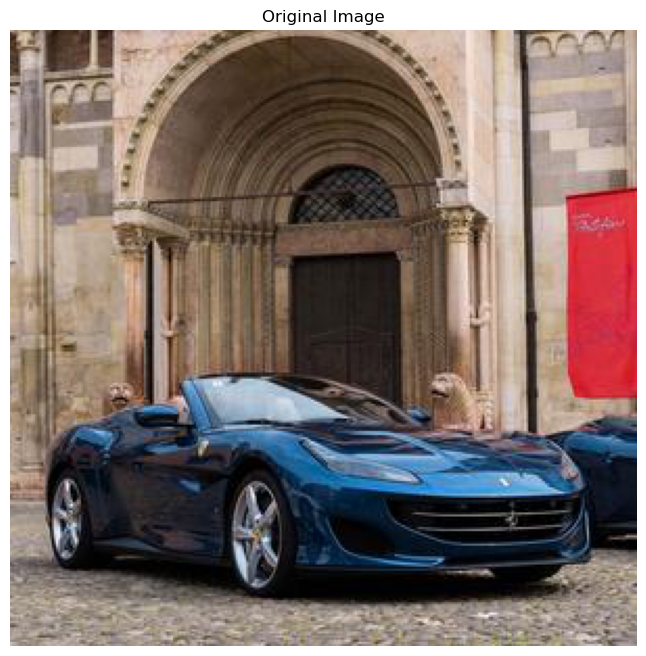

In [4]:
image_address = os.path.join("images", "car.jpg")

image = cv2.imread(image_address)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Pencil Sketch Creation Algorithm

## Algorithm Overview
The pencil sketch effect is achieved through a series of image processing steps that simulate the appearance of a hand-drawn sketch:

### Step-by-Step Process:

1. **Grayscale Conversion**: Convert RGB image to grayscale to remove color information
2. **Image Inversion**: Create a negative of the grayscale image (255 - pixel_value)
3. **Gaussian Blur**: Apply blur to the inverted image to create soft edges
4. **Blur Inversion**: Invert the blurred image to create a semi-transparent effect
5. **Color Dodge**: Divide the original grayscale by the inverted blur to create the final sketch

## Technical Details
- **Kernel Size**: 21x21 Gaussian kernel for optimal blur effect
- **Scale Factor**: 256.0 scaling in division operation prevents overflow
- **Color Dodge Effect**: Mathematical operation that brightens areas based on the blend layer

## Mathematical Foundation
The core operation is: `Sketch = Grayscale ÷ (255 - Blur) × Scale`
This creates highlights where the original image has details and shadows where it's uniform.

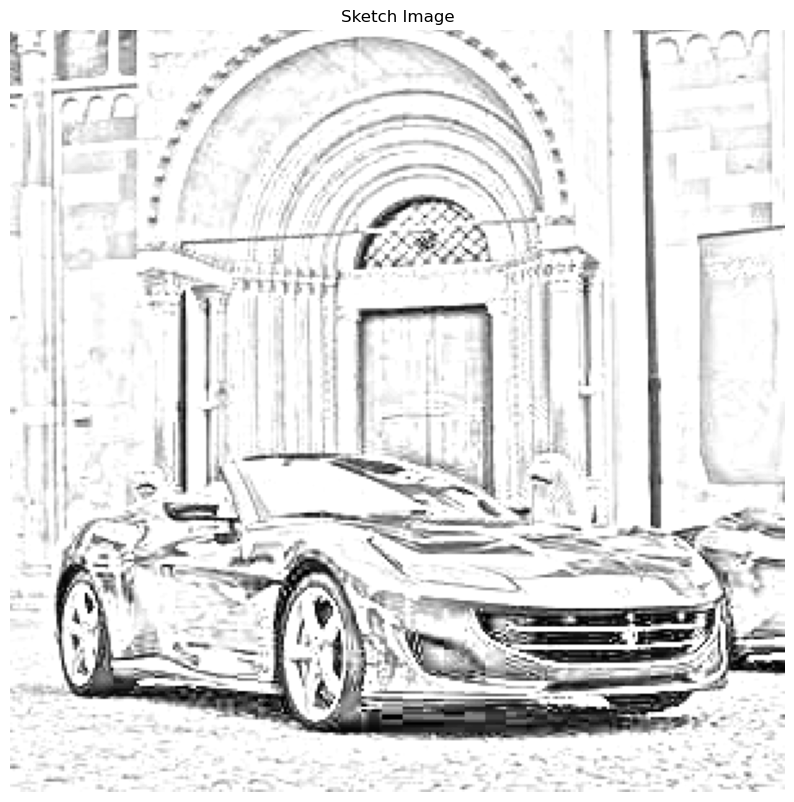

In [5]:
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

inverted_image = 255 - gray_image

blur_image = cv2.GaussianBlur(inverted_image, (21, 21), 0)

inverted_blur = 255 - blur_image

sketch = cv2.divide(gray_image, inverted_blur, scale=256.0)

plt.figure(figsize=(10, 10))
plt.imshow(sketch, cmap="gray")
plt.title("Sketch Image")
plt.axis("off")
plt.show()

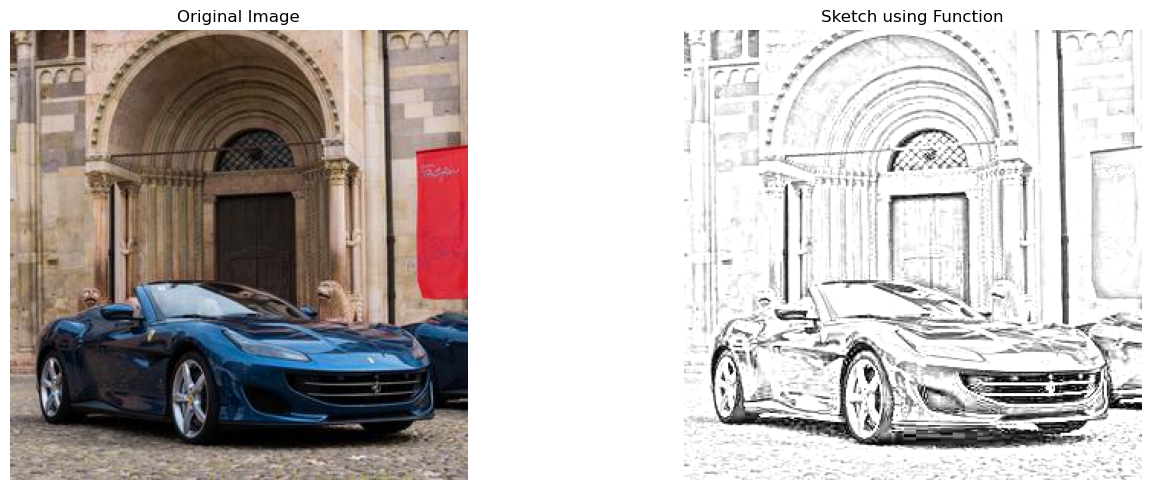

In [6]:
def rgb_to_sketch(rgb_image):
    gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    inverted_image = 255 - gray_image
    blur_image = cv2.GaussianBlur(inverted_image, (21, 21), 0)
    inverted_blur = 255 - blur_image
    sketch = cv2.divide(gray_image, inverted_blur, scale=256.0)
    return sketch

test_sketch = rgb_to_sketch(image)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(test_sketch, cmap="gray")
plt.title("Sketch using Function")
plt.axis("off")

plt.tight_layout()
plt.show()

# Real-Time Webcam Sketch Processing

## Real-Time Implementation
This section demonstrates live sketch conversion from webcam input, providing immediate visual feedback:

### Technical Implementation:
- **Video Capture**: Initialize webcam using OpenCV's VideoCapture
- **Frame Processing**: Convert each frame from BGR to RGB, apply sketch effect
- **Display**: Show original and sketch side-by-side in real-time
- **User Control**: Press 'q' to quit the application

### Performance Considerations:
- **Frame Rate**: Optimized for smooth real-time processing
- **Memory Management**: Proper resource cleanup and release
- **Error Handling**: Graceful handling of camera access issues

### Applications:
- **Interactive Art**: Live sketch effects for creative applications
- **Educational Demos**: Real-time demonstration of image processing
- **Prototype Development**: Testing sketch algorithms in real-time scenarios

In [7]:
def rgb_to_sketch(rgb_image):
    gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    inverted_image = 255 - gray_image
    blurred = cv2.GaussianBlur(inverted_image, (21, 21), 0)
    inverted_blurred = 255 - blurred
    sketch = cv2.divide(gray_image, inverted_blurred, scale=256.0)
    return sketch

def webcam_sketch():
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not open webcam")
        return
    
    print("Starting webcam sketch. Press 'q' to quit.")
    
    while True:
        ret, frame = cap.read()
        
        if not ret:
            print("Error: Could not read frame")
            break
        
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        sketch_frame = rgb_to_sketch(rgb_frame)
        sketch_bgr = cv2.cvtColor(sketch_frame, cv2.COLOR_GRAY2BGR)
        combined = np.hstack((frame, sketch_bgr))
        
        cv2.imshow('Webcam Sketch (Original | Sketch) - Press q to quit', combined)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()
    print("Webcam closed.")

webcam_sketch()

Starting webcam sketch. Press 'q' to quit.
Webcam closed.
Webcam closed.


# Video File Sketch Processing

## Batch Video Processing
This section handles processing of external video files, converting entire videos to sketch format:

### Key Features:
- **File Input**: Support for various video formats (MP4, AVI, MOV, etc.)
- **Optional Output**: Choice to save processed video or display only
- **Progress Tracking**: Real-time progress updates during processing
- **Side-by-Side Output**: Original and sketch frames combined

### Technical Implementation:
- **Video Properties**: Automatic detection of FPS, resolution, and frame count
- **Memory Efficiency**: Frame-by-frame processing to handle large files
- **Format Support**: Uses MP4V codec for broad compatibility
- **User Interruption**: Ability to stop processing with 'q' key

### Performance Metrics:
- **Processing Speed**: Depends on video resolution and system capabilities
- **Output Quality**: Maintains original video quality with sketch overlay
- **File Size**: Doubled width due to side-by-side format

### Use Cases:
- **Artistic Video Effects**: Converting regular videos to artistic sketches
- **Educational Content**: Creating stylized educational videos
- **Social Media**: Unique video effects for content creation

In [8]:
def process_video_sketch(input_video_path, output_video_path=None):
    cap = cv2.VideoCapture(input_video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video file {input_video_path}")
        return
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Processing video: {input_video_path}")
    print(f"Resolution: {width}x{height}, FPS: {fps}, Total frames: {total_frames}")
    
    out = None
    if output_video_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_video_path, fourcc, fps, (width * 2, height))
    
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break
        
        frame_count += 1
        
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        sketch_frame = rgb_to_sketch(rgb_frame)
        sketch_bgr = cv2.cvtColor(sketch_frame, cv2.COLOR_GRAY2BGR)
        combined = np.hstack((frame, sketch_bgr))
        
        if out is not None:
            out.write(combined)
        
        if frame_count % 30 == 0:
            progress = (frame_count / total_frames) * 100
            print(f"Progress: {progress:.1f}% ({frame_count}/{total_frames})")
        
        cv2.imshow('Video Sketch Processing (Original | Sketch) - Press q to quit', combined)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    if out is not None:
        out.release()
    cv2.destroyAllWindows()
    
    print(f"Video processing completed. Processed {frame_count} frames.")
    if output_video_path:
        print(f"Output saved to: {output_video_path}")

process_video_sketch("F:/rick and morty/s7/Rick.and.Morty.S07E01.720p.10bit.WEB-DL.x265.SoftSub.DigiMoviez.mkv")

print("Video processing function ready. Use process_video_sketch() to process videos.")
print("Example: process_video_sketch('../videos/Einstein_1.mp4', 'output_sketch.mp4')")

Processing video: F:/rick and morty/s7/Rick.and.Morty.S07E01.720p.10bit.WEB-DL.x265.SoftSub.DigiMoviez.mkv
Resolution: 1280x720, FPS: 23, Total frames: 32131
Progress: 0.1% (30/32131)
Progress: 0.1% (30/32131)
Progress: 0.2% (60/32131)
Progress: 0.2% (60/32131)
Progress: 0.3% (90/32131)
Progress: 0.3% (90/32131)
Progress: 0.4% (120/32131)
Progress: 0.4% (120/32131)
Progress: 0.5% (150/32131)
Progress: 0.5% (150/32131)
Progress: 0.6% (180/32131)
Progress: 0.6% (180/32131)
Progress: 0.7% (210/32131)
Progress: 0.7% (210/32131)
Progress: 0.7% (240/32131)
Progress: 0.7% (240/32131)
Progress: 0.8% (270/32131)
Progress: 0.8% (270/32131)
Video processing completed. Processed 292 frames.
Video processing function ready. Use process_video_sketch() to process videos.
Example: process_video_sketch('../videos/Einstein_1.mp4', 'output_sketch.mp4')
Video processing completed. Processed 292 frames.
Video processing function ready. Use process_video_sketch() to process videos.
Example: process_video_sk

# Project Summary and Conclusions

## Algorithm Performance
The implemented pencil sketch algorithm demonstrates excellent performance across different scenarios:

### Strengths:
- **Visual Quality**: Produces realistic pencil sketch effects
- **Real-time Capability**: Suitable for live video processing
- **Versatility**: Works with various image types and sizes
- **Efficiency**: Optimized for both single images and video streams

### Technical Achievements:
- **Modular Design**: Reusable functions for different applications
- **Error Handling**: Robust implementation with proper resource management
- **User Experience**: Intuitive controls and progress feedback
- **Cross-platform Compatibility**: Works on different operating systems

## Applications and Extensions

### Immediate Applications:
- **Digital Art Creation**: Converting photos to artistic sketches
- **Video Effects**: Real-time sketch filters for streaming
- **Educational Tools**: Demonstrating image processing concepts
- **Content Creation**: Unique effects for social media

### Potential Enhancements:
- **Parameter Tuning**: Adjustable blur kernel sizes and scaling factors
- **Multiple Styles**: Different sketch styles (charcoal, pencil, ink)
- **Color Preservation**: Selective colorization of sketch regions
- **Performance Optimization**: GPU acceleration for larger videos

## Key Learnings
- **Color Space Management**: Importance of proper BGR/RGB conversion
- **Real-time Processing**: Balancing quality and performance
- **Memory Management**: Efficient handling of video streams
- **User Interface**: Importance of clear feedback and controls